# Phase 1: load the libraries and data

In [21]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set a clean, professional aesthetic for our charts
sns.set_theme(style="whitegrid")
print("Libraries successfully loaded!")

# Load the data we saved at the end of the previous notebook
file_path = "../data/clean_cervical_cancer_data_ntb.csv"
df = pd.read_csv(file_path)

print(f"Data loaded! Shape: {df.shape[0]} patients and {df.shape[1]} features.")
df.head()

Libraries successfully loaded!
Data loaded! Shape: 827 patients and 53 features.


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:vaginal condylomatosis_is_missing,STDs:vulvo-perineal condylomatosis_is_missing,STDs:syphilis_is_missing,STDs:pelvic inflammatory disease_is_missing,STDs:genital herpes_is_missing,STDs:molluscum contagiosum_is_missing,STDs:AIDS_is_missing,STDs:HIV_is_missing,STDs:Hepatitis B_is_missing,STDs:HPV_is_missing
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,0,0,0


# Phase 2: Visual exploration

### Step 1: Plot the count of positive vs negative biopsies

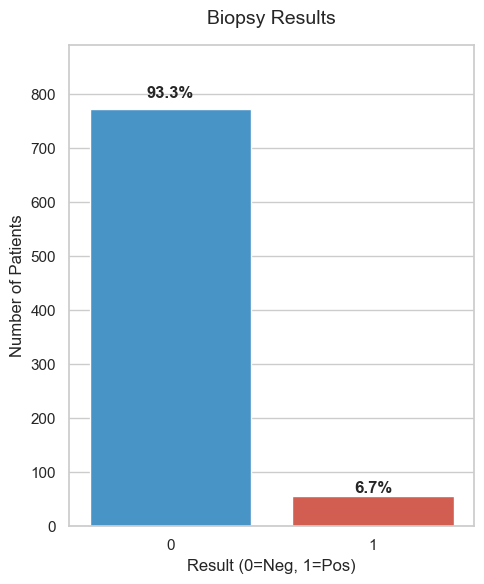

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Narrow the figure size to fit the side of a slide (width, height)
plt.figure(figsize=(5, 6))

# Plot the count of positive vs negative biopsies
# 2. Add the 'width' parameter to thin the columns
ax = sns.countplot(
    data=df, 
    x='Biopsy', 
    hue='Biopsy', 
    palette=['#3498db', '#e74c3c'], 
    legend=False,
    width=0.8  # Decreased from default to make columns thinner
)

# Consider shortening titles/labels if the narrow canvas cuts them off
plt.title("Biopsy Results", fontsize=14, pad=15)
plt.xlabel("Result (0=Neg, 1=Pos)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add percentage labels on top of the bars for clarity
total_patients = len(df)
for p in ax.patches:
    height = p.get_height()
    # Ensure empty patches don't cause issues
    if height > 0: 
        percentage = f'{100 * height / total_patients:.1f}%'
        
        # FIX: Calculate exact center and use ha='center' instead of manual offset
        x = p.get_x() + p.get_width() / 2
        # FIX: Use a proportional dynamic offset (2% of height) instead of a hardcoded +10
        y = height + (height * 0.02) 
        
        ax.annotate(percentage, (x, y), ha='center', va='bottom', size=12, fontweight='bold')

# Expand y-limit slightly to guarantee top annotations are not cropped
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# 3. Apply tight_layout to prevent bounding box clipping on a narrow canvas
plt.tight_layout()
plt.show()

### Step 2: Plot the correlation matrix

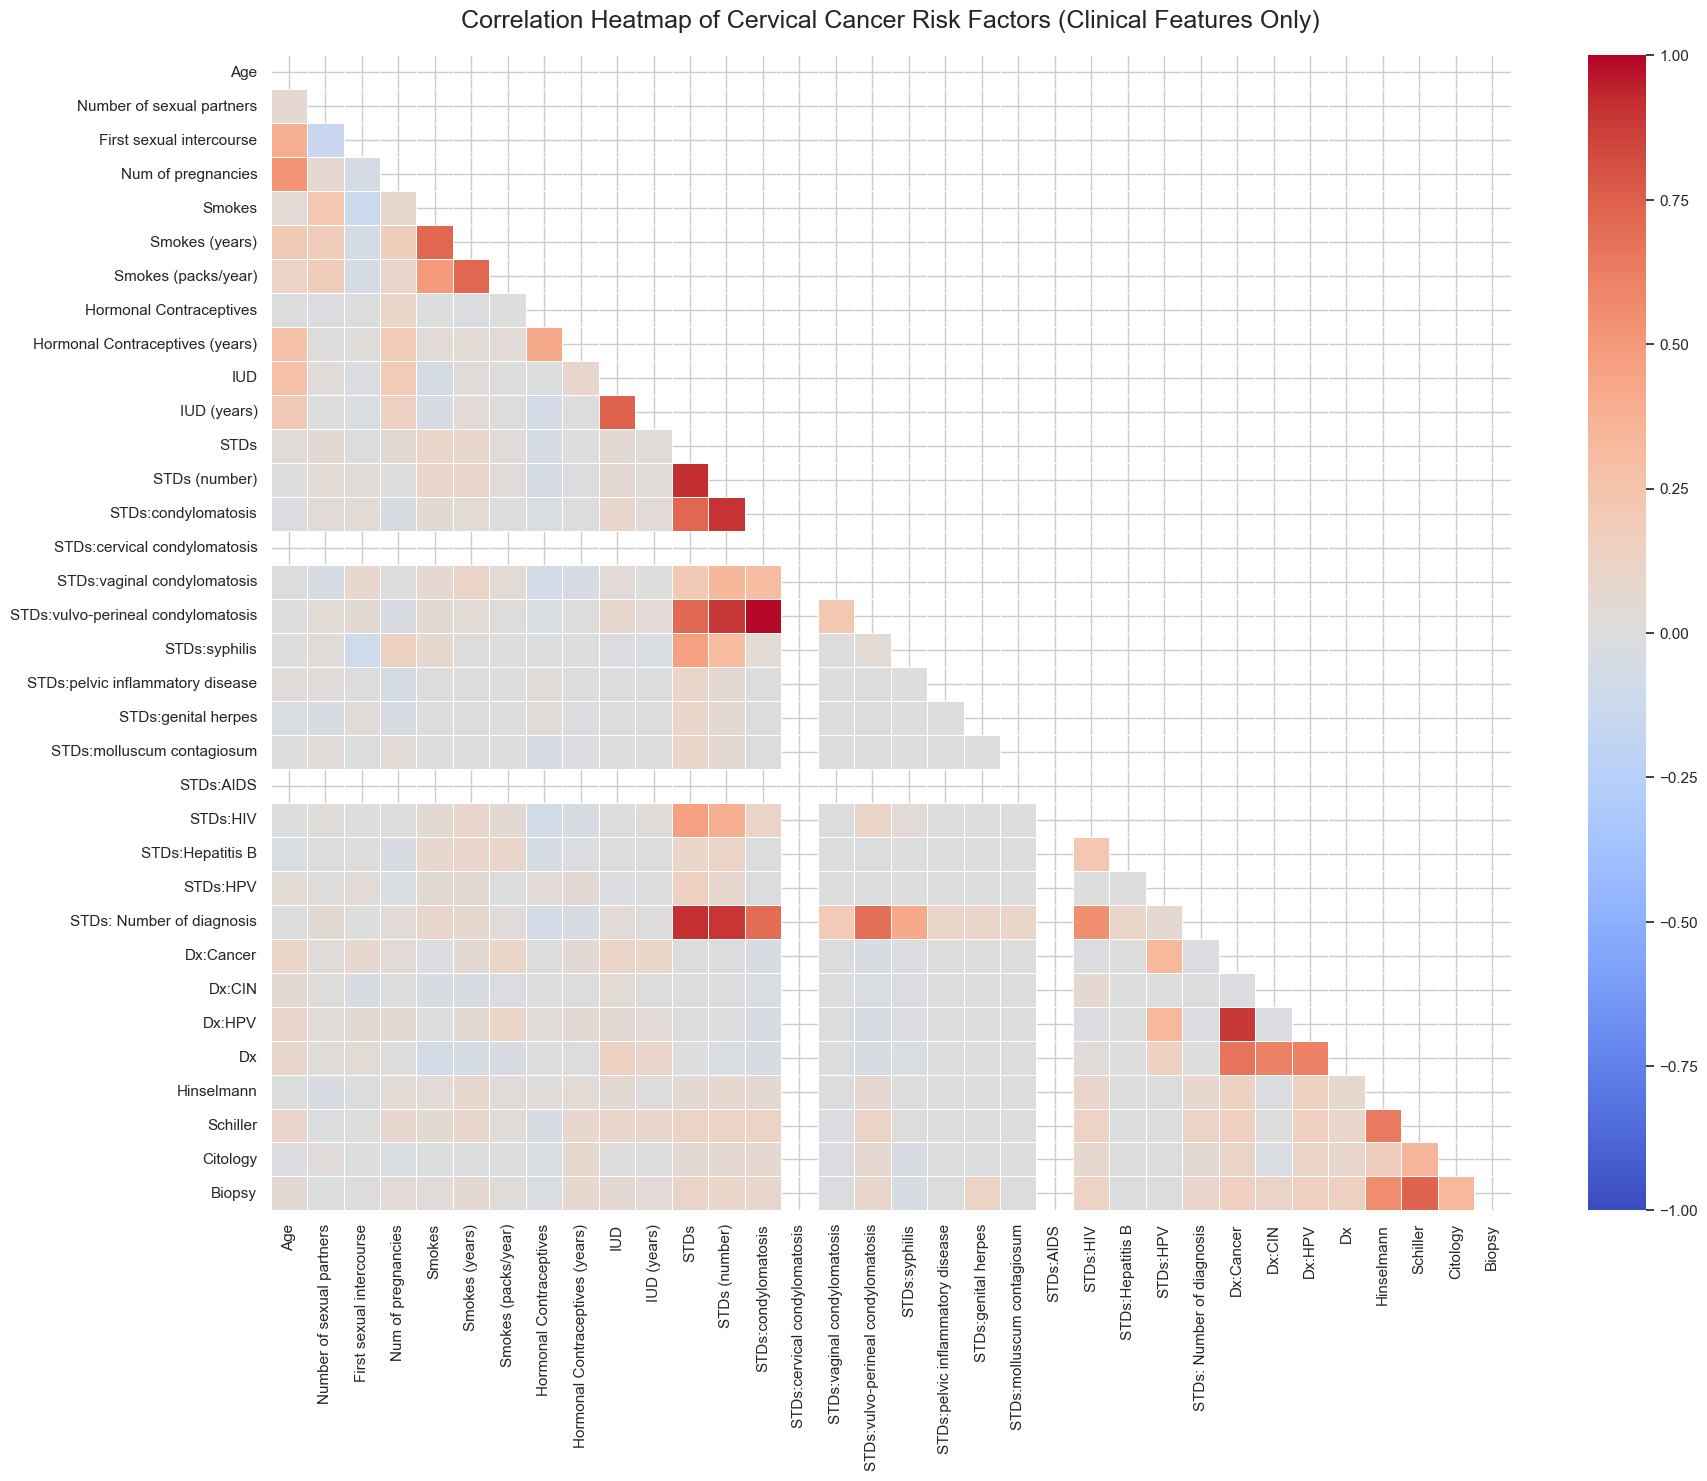

In [23]:
# %%
# Cell 3
plt.figure(figsize=(20, 15))

# Filter out the shadow matrix so we only see clinical features
clinical_cols = [col for col in df.columns if not col.endswith('_is_missing')]

# Calculate the correlation matrix
corr_matrix = df[clinical_cols].corr()

# Create a mask to hide the upper triangle (prevents duplicate visual info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=False, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            linewidths=0.5)

plt.title("Correlation Heatmap of Cervical Cancer Risk Factors (Clinical Features Only)", fontsize=18, pad=20)
plt.show()

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate correlations specifically with the Target Variable (Biopsy)
print("--- Top Linear Predictors for Biopsy ---")
target_corr = corr_matrix['Biopsy'].drop('Biopsy').sort_values(ascending=False)
print(target_corr.head(10).round(3))

# 2. Find the "Dark Red" Multicollinearity points (Warning threshold > 0.75)
print("\n--- Severe Feature Multicollinearity (Risk of Matrix Collapse) ---")
# Unstack the matrix, sort it, and drop perfect self-correlations (1.0)
high_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
high_corr = high_corr[(high_corr > 0.75) & (high_corr < 1.0)]
print(high_corr.round(3))

--- Top Linear Predictors for Biopsy ---
Schiller               0.738
Hinselmann             0.556
Citology               0.331
Dx:HPV                 0.160
Dx:Cancer              0.160
Dx                     0.156
STDs:genital herpes    0.130
STDs:HIV               0.126
STDs                   0.113
Dx:CIN                 0.112
Name: Biopsy, dtype: float64

--- Severe Feature Multicollinearity (Risk of Matrix Collapse) ---
STDs:vulvo-perineal condylomatosis  STDs:condylomatosis          0.988
STDs (number)                       STDs                         0.918
STDs: Number of diagnosis           STDs                         0.906
STDs:condylomatosis                 STDs (number)                0.899
STDs (number)                       STDs: Number of diagnosis    0.897
STDs:vulvo-perineal condylomatosis  STDs (number)                0.890
Dx:Cancer                           Dx:HPV                       0.886
dtype: float64


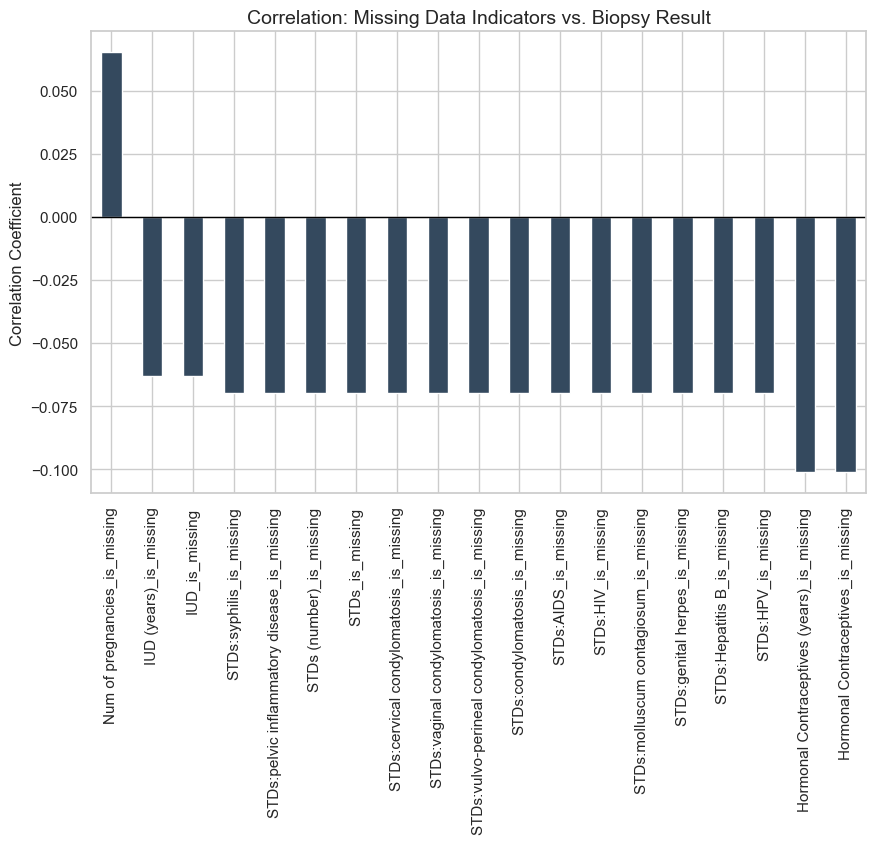

--- Clinical Insight ---
High positive correlation here suggests that missing data is 'Non-Random'.
It implies the absence of information is itself a risk-predictive signal.


In [25]:
# %% [markdown]
# ### Step 2.b: Missingness Pattern Analysis
# Investigating if the 'Act of Missing Data' correlates with the Biopsy result.

# %%
plt.figure(figsize=(10, 6))

# Isolate the missingness indicators and the target
missing_cols = [col for col in df.columns if col.endswith('_is_missing')]
target_corr_missing = df[missing_cols + ['Biopsy']].corr()['Biopsy'].sort_values(ascending=False)

# Plot only the correlation of missingness with Biopsy
target_corr_missing.drop('Biopsy').plot(kind='bar', color='#34495e')

plt.title("Correlation: Missing Data Indicators vs. Biopsy Result", fontsize=14)
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color='black', lw=1)
plt.show()

print("--- Clinical Insight ---")
print("High positive correlation here suggests that missing data is 'Non-Random'.")
print("It implies the absence of information is itself a risk-predictive signal.")

### Step 3: Investigating zero-variance and collinearity

In [26]:
# Cell 4
print("==========================================")
print("PHASE 2, STEP 3: FEATURE INVESTIGATION")
print("==========================================")

# ---------------------------------------------------------
# Part A: Prove Zero-Variance
# ---------------------------------------------------------
print("--- Part A: Zero-Variance Check ---")
suspect_cols = ['STDs:cervical condylomatosis', 'STDs:AIDS']

for col in suspect_cols:
    unique_vals = df[col].unique()
    print(f"Unique values in '{col}': {unique_vals}")

# ---------------------------------------------------------
# Part B: Identify Highly Correlated Pairs
# ---------------------------------------------------------
print("\n--- Part B: High Correlation Pairs (> 0.80) ---")

# Calculate absolute correlation (so we catch strong negative correlations too)
corr_matrix_abs = df.corr().abs()

# Keep only the upper triangle to avoid duplicating A vs B and B vs A
upper_mask = np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
upper = corr_matrix_abs.where(upper_mask)

# Set our threshold
threshold = 0.80

# Stack the matrix and filter by the threshold
stacked = upper.stack()
high_corr_pairs = stacked[stacked > threshold]

# Update your Cell 4 Part B logic:
# Filter out pairs that are just two missingness indicators of the same group
filtered_pairs = []
for index, value in high_corr_pairs.items():
    feat_A, feat_B = index
    # Ignore if both are missingness indicators (they are expected to be correlated)
    if not (feat_A.endswith('_is_missing') and feat_B.endswith('_is_missing')):
        print(f"- {feat_A:30} <---> {feat_B:30} (Corr: {value:.2f})")

PHASE 2, STEP 3: FEATURE INVESTIGATION
--- Part A: Zero-Variance Check ---
Unique values in 'STDs:cervical condylomatosis': [0.]
Unique values in 'STDs:AIDS': [0.]

--- Part B: High Correlation Pairs (> 0.80) ---
- STDs                           <---> STDs (number)                  (Corr: 0.92)
- STDs                           <---> STDs: Number of diagnosis      (Corr: 0.91)
- STDs (number)                  <---> STDs:condylomatosis            (Corr: 0.90)
- STDs (number)                  <---> STDs:vulvo-perineal condylomatosis (Corr: 0.89)
- STDs (number)                  <---> STDs: Number of diagnosis      (Corr: 0.90)
- STDs:condylomatosis            <---> STDs:vulvo-perineal condylomatosis (Corr: 0.99)
- Dx:Cancer                      <---> Dx:HPV                         (Corr: 0.89)


### Step 4: Condylomatosis Verification and final drops

In [27]:
# %%
# Cell 5
print("==========================================")
print("PHASE 2, STEP 4: VERIFICATION & DROPPING")
print("==========================================")

# ---------------------------------------------------------
# Part A: Verify the Condylomatosis Hypothesis
# ---------------------------------------------------------
print("--- Part A: Condylomatosis Logic Check ---")

# Gather the specific condylomatosis columns
specific_condy_cols = ['STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis']

# Create a flag: 1 if they have ANY specific condylomatosis, 0 if not
has_specific_condy = (df[specific_condy_cols].sum(axis=1) > 0).astype(int)

# Check if this flag perfectly matches the master 'STDs:condylomatosis' column
mismatches = df[df['STDs:condylomatosis'] != has_specific_condy]
print(f"Number of patients where master 'condylomatosis' contradicts the specific columns: {len(mismatches)}")

# ---------------------------------------------------------
# Part B: Execute the Drops
# ---------------------------------------------------------
print("\n--- Part B: Dropping Redundant, Empty & Noise Features ---")

# 1. Zero Variance and Redundant Columns
columns_to_drop = [
    'STDs:cervical condylomatosis', # Zero variance
    'STDs:AIDS',                    # Zero variance
    'STDs'                          # Redundant to 'STDs (number)' which holds more granular clinical value
]

if len(mismatches) == 0:
    print("-> Hypothesis confirmed! 'STDs:condylomatosis' is a redundant master column. Adding to drop list.")
    columns_to_drop.append('STDs:condylomatosis')

# 2. Drop the Shadow Matrix (Missingness Indicators)
# Justified by Step 2.b: The missingness has an absolute correlation < 0.1 with the target.
shadow_cols = [col for col in df.columns if col.endswith('_is_missing')]
print(f"-> Adding {len(shadow_cols)} non-predictive '_is_missing' shadow columns to drop list.")
columns_to_drop.extend(shadow_cols)

# Execute the drop
df_final = df.drop(columns=columns_to_drop, errors='ignore')

print(f"\nSuccessfully dropped {len(columns_to_drop)} columns.")
print(f"Original Shape: {df.shape}")
print(f"Final Cleaned Shape: {df_final.shape}")

# Overwrite our working dataframe with the final version
df = df_final

PHASE 2, STEP 4: VERIFICATION & DROPPING
--- Part A: Condylomatosis Logic Check ---
Number of patients where master 'condylomatosis' contradicts the specific columns: 0

--- Part B: Dropping Redundant, Empty & Noise Features ---
-> Hypothesis confirmed! 'STDs:condylomatosis' is a redundant master column. Adding to drop list.
-> Adding 19 non-predictive '_is_missing' shadow columns to drop list.

Successfully dropped 23 columns.
Original Shape: (827, 53)
Final Cleaned Shape: (827, 30)


In [28]:
# Cell 6 #TODO
# print("--- Fixing Data Leakage ---")

# # Drop the concurrent medical tests
# leakage_cols = ['Schiller', 'Hinselmann', 'Citology']
# df = df.drop(columns=leakage_cols, errors='ignore')

# print(f"Dropped {len(leakage_cols)} data-leaking test columns.")
# print(f"New dataset shape: {df.shape[0]} patients and {df.shape[1]} features.")

# Phase 3: Clean data visual exploration

### Step 1: Cleaned correlation matrix

PHASE 3: CLEAN DATA VISUAL EXPLORATION
--- Step 1: Cleaned Correlation Matrix ---


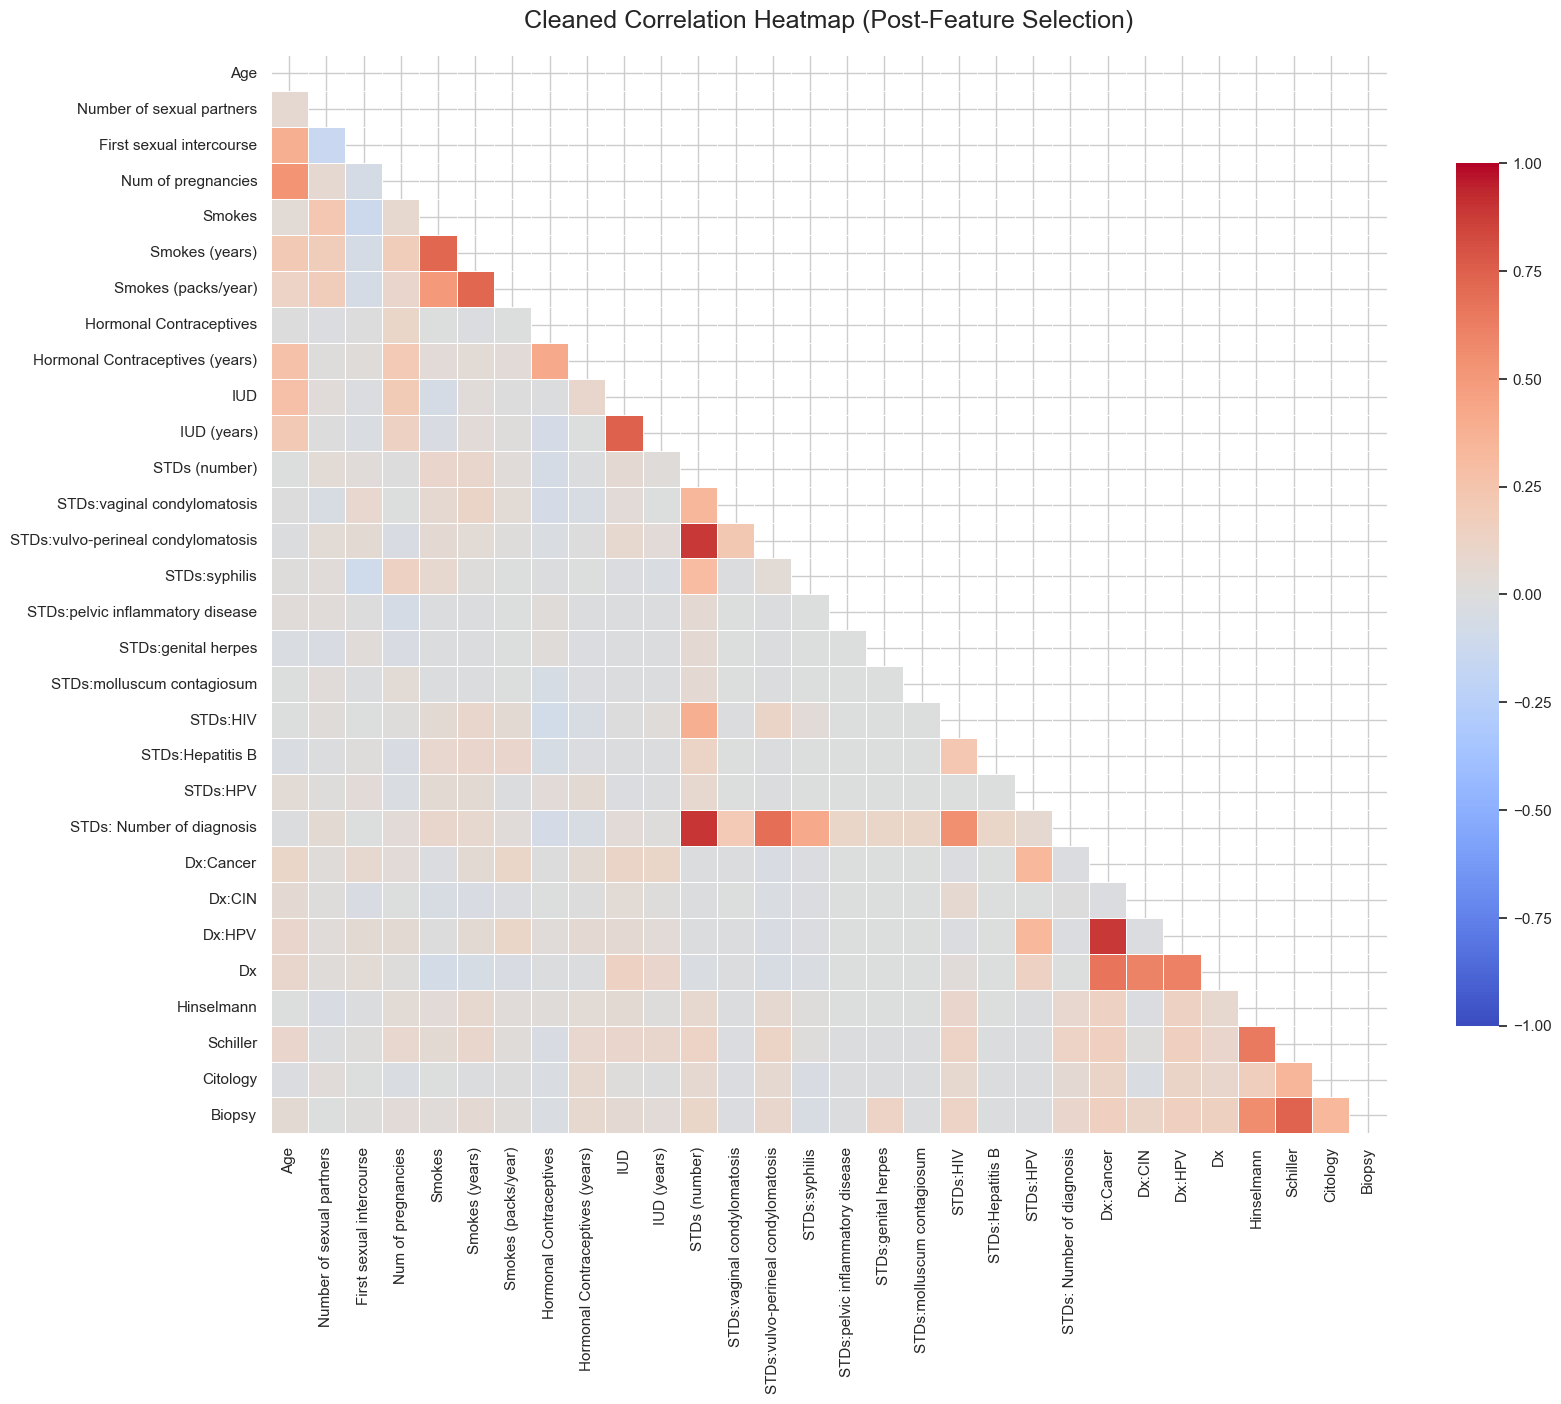


--- Top Features Correlated with Positive Biopsy ---
Schiller      0.738
Hinselmann    0.556
Citology      0.331
Dx:HPV        0.160
Dx:Cancer     0.160
Name: Biopsy, dtype: float64


In [29]:
# Cell 7
print("==========================================")
print("PHASE 3: CLEAN DATA VISUAL EXPLORATION")
print("==========================================")
print("--- Step 1: Cleaned Correlation Matrix ---")

# Set up the canvas
plt.figure(figsize=(18, 14))

# Calculate the new correlation matrix on the cleaned dataframe
clean_corr = df.corr()

# Create the mask to hide the upper triangle
mask = np.triu(np.ones_like(clean_corr, dtype=bool))

# Plot the heatmap
sns.heatmap(clean_corr, 
            mask=mask, 
            annot=False, # Keeping this False so it remains readable
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) # Shrinks the colorbar slightly for aesthetics

plt.title("Cleaned Correlation Heatmap (Post-Feature Selection)", fontsize=18, pad=20)
plt.show()

# Let's also print the top correlations strictly with our Target Variable (Biopsy)
print("\n--- Top Features Correlated with Positive Biopsy ---")
target_corr = clean_corr['Biopsy'].drop('Biopsy').sort_values(ascending=False)
print(target_corr.head(5).round(3))

C:\Users\LegoR\AppData\Local\Temp\ipykernel_21224\3727152923.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_values.values, y=top_corr_values.index, palette='viridis')


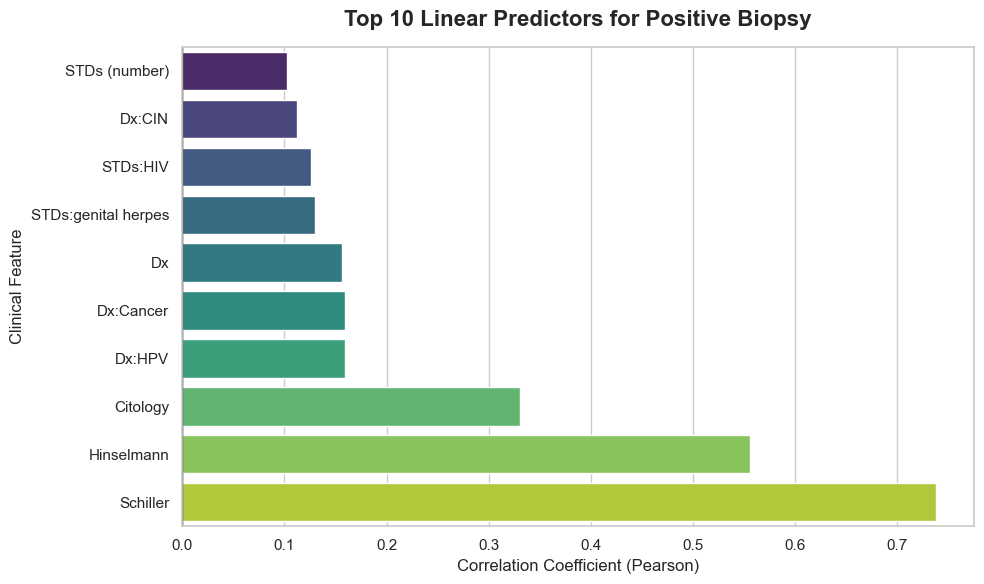

In [35]:
plt.figure(figsize=(10, 6))

# 1. Get correlations with 'Biopsy', drop Biopsy itself, and take the absolute top 10
# (Using absolute value to catch strong negative predictors too, if they exist)
target_corr = clean_corr['Biopsy'].drop('Biopsy')
top_features = target_corr.abs().sort_values(ascending=False).head(10).index
top_corr_values = target_corr[top_features].sort_values()

# 2. Plot as a clean horizontal bar chart
sns.barplot(x=top_corr_values.values, y=top_corr_values.index, palette='viridis')

plt.title("Top 10 Linear Predictors for Positive Biopsy", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Correlation Coefficient (Pearson)", fontsize=12)
plt.ylabel("Clinical Feature", fontsize=12)

# Add a vertical line at 0 for visual grounding
plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

### Step 2: Continuous feature investigation

PHASE 3, STEP 2: CONTINUOUS FEATURE INVESTIGATION


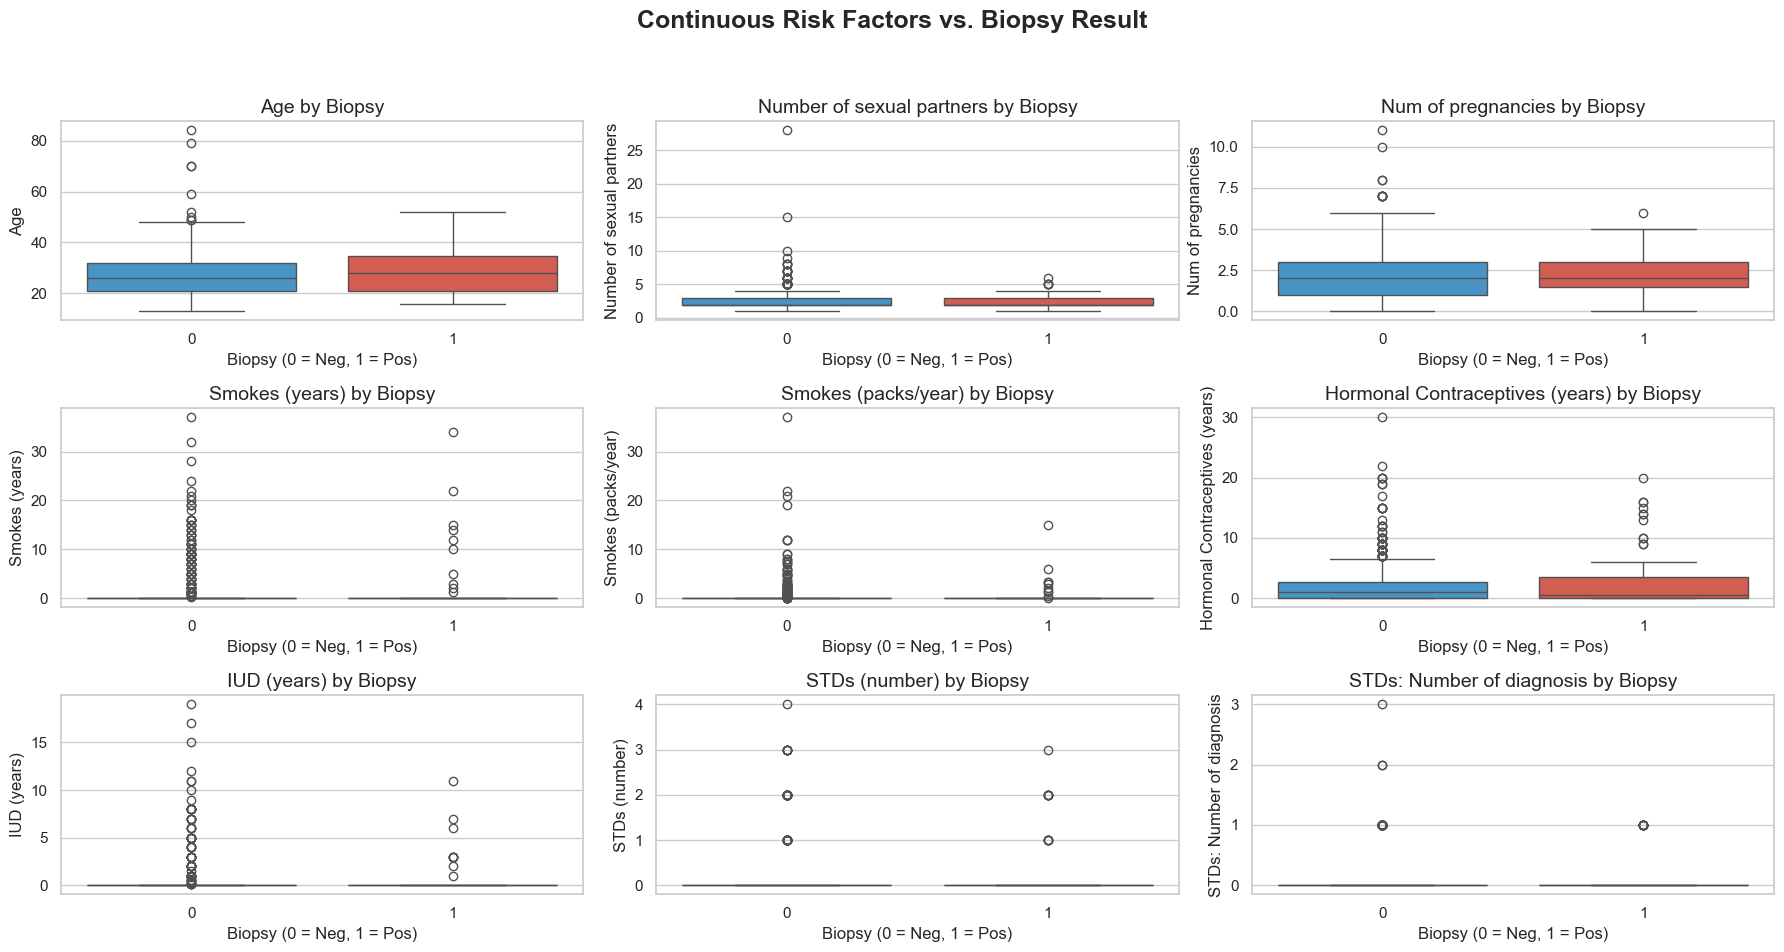

In [30]:
# Cell 8
print("==========================================")
print("PHASE 3, STEP 2: CONTINUOUS FEATURE INVESTIGATION")
print("==========================================")

# List of the main continuous features we want to investigate
continuous_features = [
    'Age', 
    'Number of sexual partners', 
    'Num of pregnancies', 
    'Smokes (years)',
    'Smokes (packs/year)',
    'Hormonal Contraceptives (years)', 
    'IUD (years)',
    'STDs (number)',
    'STDs: Number of diagnosis'
]

# Set up a grid for our plots (2 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Continuous Risk Factors vs. Biopsy Result', fontsize=18, fontweight='bold')

# Flatten the axes array so we can easily loop through it
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    # Create a boxplot for each feature, split by Biopsy result
    sns.boxplot(
        x='Biopsy', 
        y=feature, 
        data=df, 
        ax=axes[i], 
        palette=['#3498db', '#e74c3c'],
        hue='Biopsy',
        legend=False
    )
    axes[i].set_title(f'{feature} by Biopsy', fontsize=14)
    axes[i].set_xlabel('Biopsy (0 = Neg, 1 = Pos)')
    axes[i].set_ylabel(feature)

# Adjust spacing so the labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

PHASE 3, STEP 2: FEATURE DISTRIBUTION INVESTIGATION


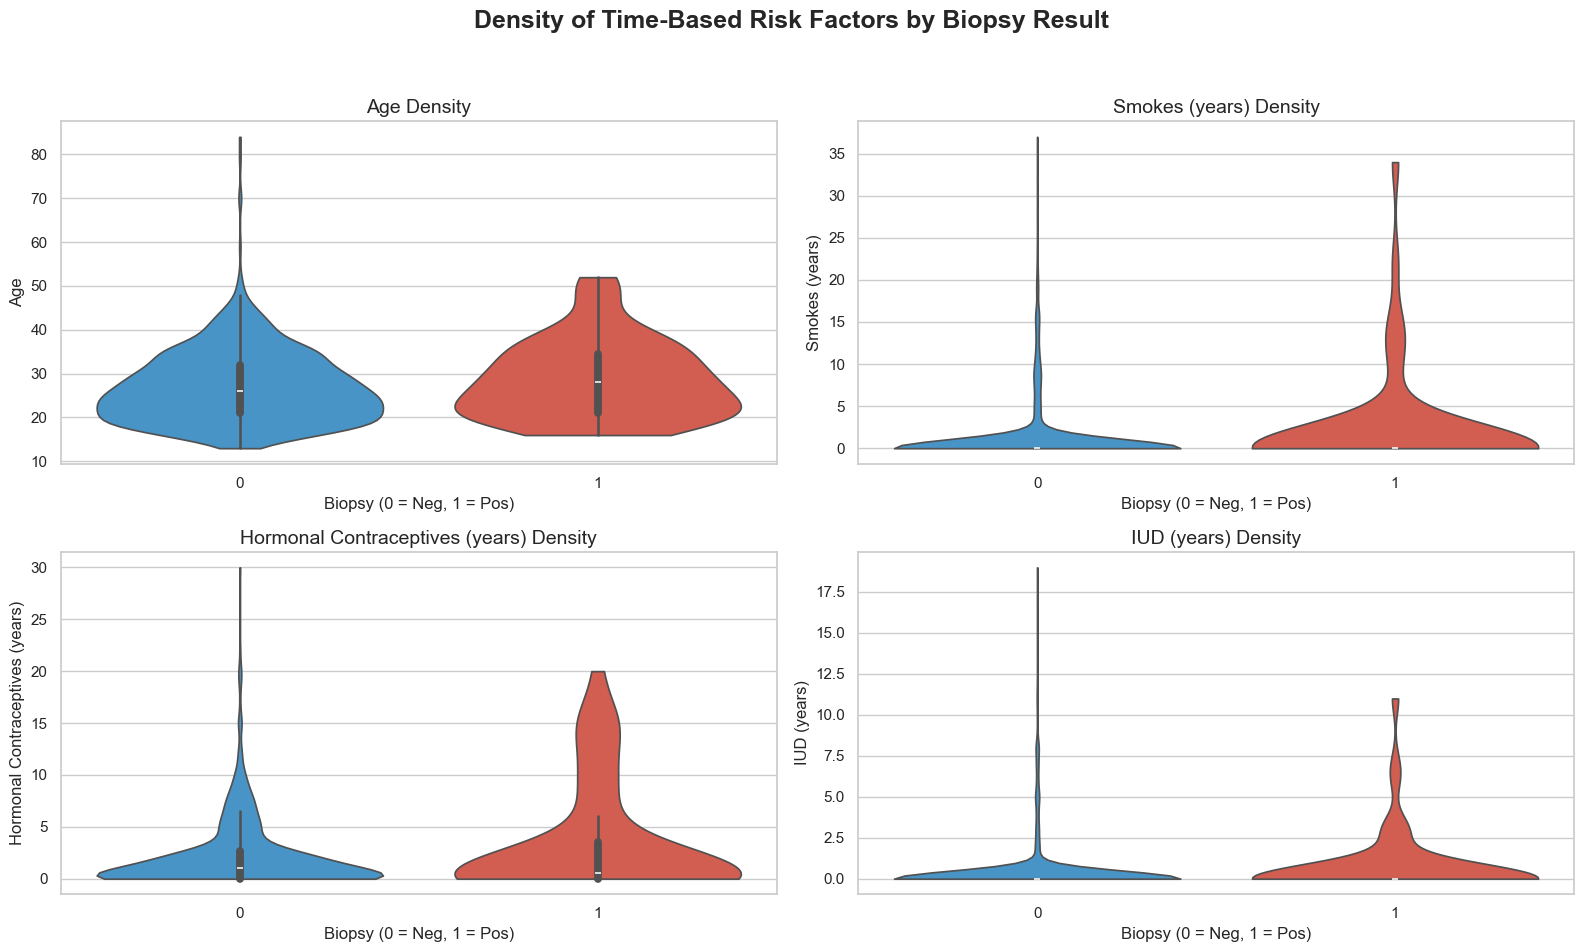

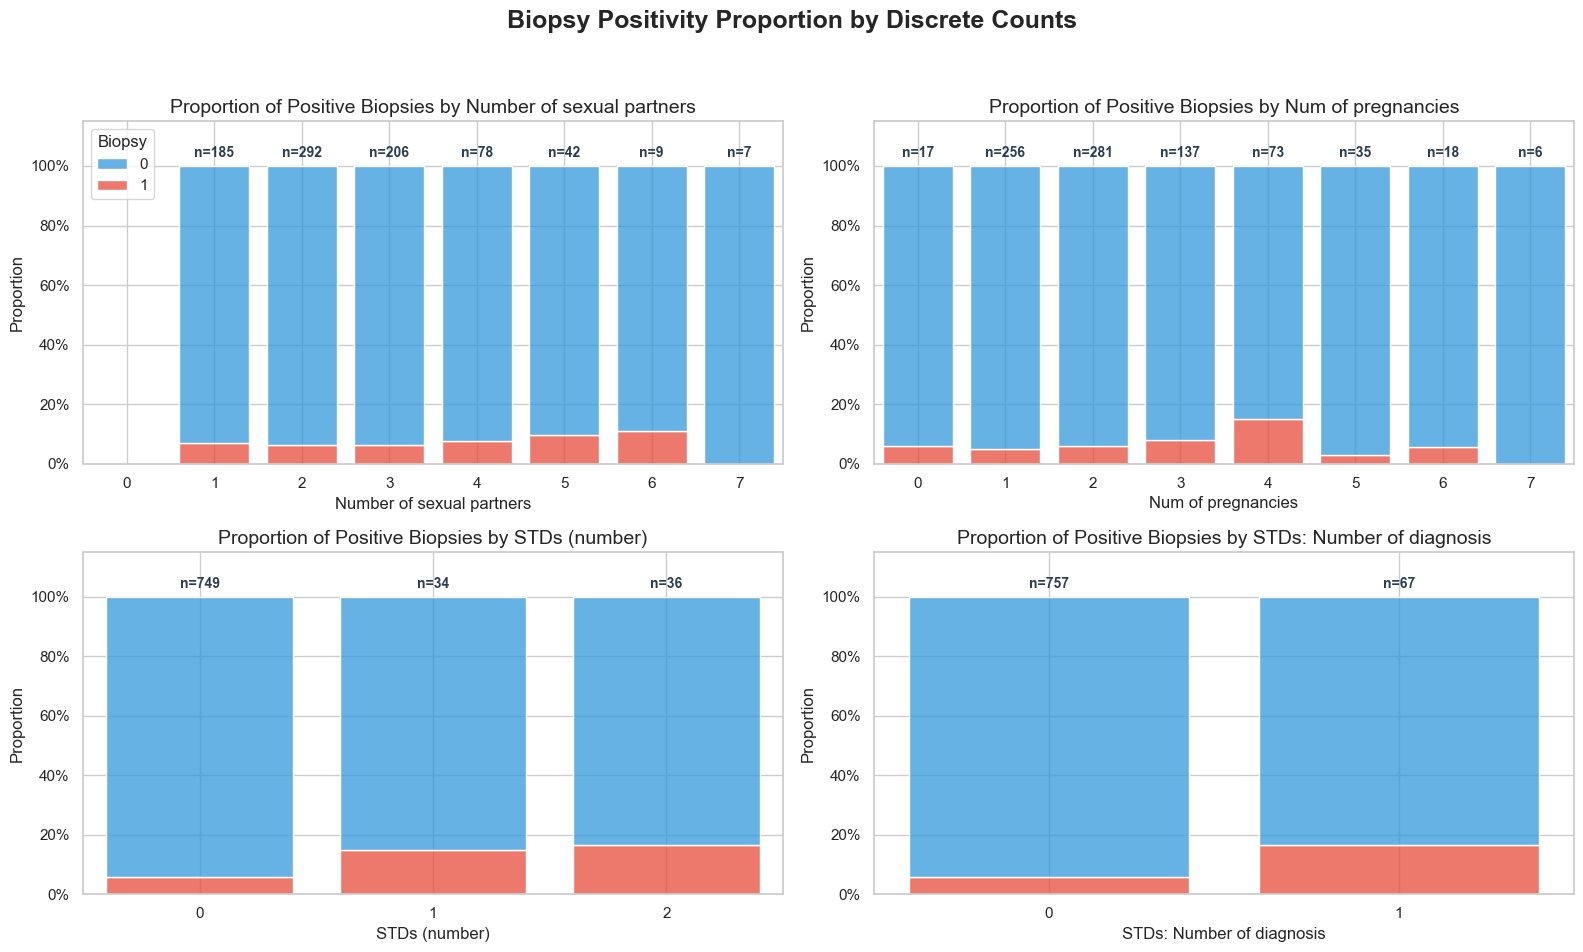

In [31]:
# %%
# Cell 8
import matplotlib.ticker as mtick

print("==========================================")
print("PHASE 3, STEP 2: FEATURE DISTRIBUTION INVESTIGATION")
print("==========================================")

# ---------------------------------------------------------
# Part A: True Continuous Features (Time/Age) -> Violin Plots
# ---------------------------------------------------------
time_features = ['Age', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)']
time_features = [f for f in time_features if f in df.columns]

if time_features:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Density of Time-Based Risk Factors by Biopsy Result', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for i, feature in enumerate(time_features):
        sns.violinplot(
            x='Biopsy', 
            y=feature, 
            data=df, 
            ax=axes[i], 
            palette=['#3498db', '#e74c3c'], 
            hue='Biopsy', 
            legend=False,
            inner='box', 
            cut=0 # Strict clinical boundary: prevents the algorithm from drawing density below 0 years
        )
        axes[i].set_title(f'{feature} Density', fontsize=14)
        axes[i].set_xlabel('Biopsy (0 = Neg, 1 = Pos)')
        axes[i].set_ylabel(feature)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# Part B: Discrete Count Features -> 100% Stacked Proportion Bars (With N-Counts)
# ---------------------------------------------------------
discrete_features = ['Number of sexual partners', 'Num of pregnancies', 'STDs (number)', 'STDs: Number of diagnosis']
discrete_features = [f for f in discrete_features if f in df.columns]

if discrete_features:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Biopsy Positivity Proportion by Discrete Counts', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for i, feature in enumerate(discrete_features):
        # 1. Plot the 100% stacked proportions
        sns.histplot(
            data=df, 
            x=feature, 
            hue='Biopsy', 
            ax=axes[i],
            multiple="fill", 
            discrete=True,   
            shrink=0.8,
            palette=['#3498db', '#e74c3c'], 
            legend=(i==0)    
        )
        
        axes[i].set_title(f'Proportion of Positive Biopsies by {feature}', fontsize=14)
        axes[i].set_ylabel('Proportion')
        axes[i].set_xlabel(feature)
        
        # Format Y-axis as percentages
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
        # Calculate the 99th percentile to clip the visual outliers
        p99 = df[feature].quantile(0.99)
        axes[i].set_xlim(left=-0.5, right=p99 + 0.5)
        
        # Force X-axis ticks to be strict integers
        axes[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        # 2. Add the Exact Counts (N) above each bar
        # We increase the Y-limit slightly so the text doesn't get cut off
        axes[i].set_ylim(0, 1.15) 
        
        # Get exact value counts for this feature
        value_counts = df[feature].value_counts().sort_index()
        
        for x_val, count in value_counts.items():
            # Only annotate the bars that are actually visible within our 99th percentile crop
            if x_val <= p99:
                axes[i].text(
                    x=x_val, 
                    y=1.02, # Placed just above the 100% mark
                    s=f'n={count}', 
                    ha='center', 
                    va='bottom', 
                    fontsize=10, 
                    color='#2c3e50',
                    fontweight='bold',
                    # rotation=45 # Rotated slightly so high-density numbers don't overlap
                )

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Step 3: Categorical feature investigation

PHASE 3, STEP 3: CATEGORICAL FEATURE INVESTIGATION


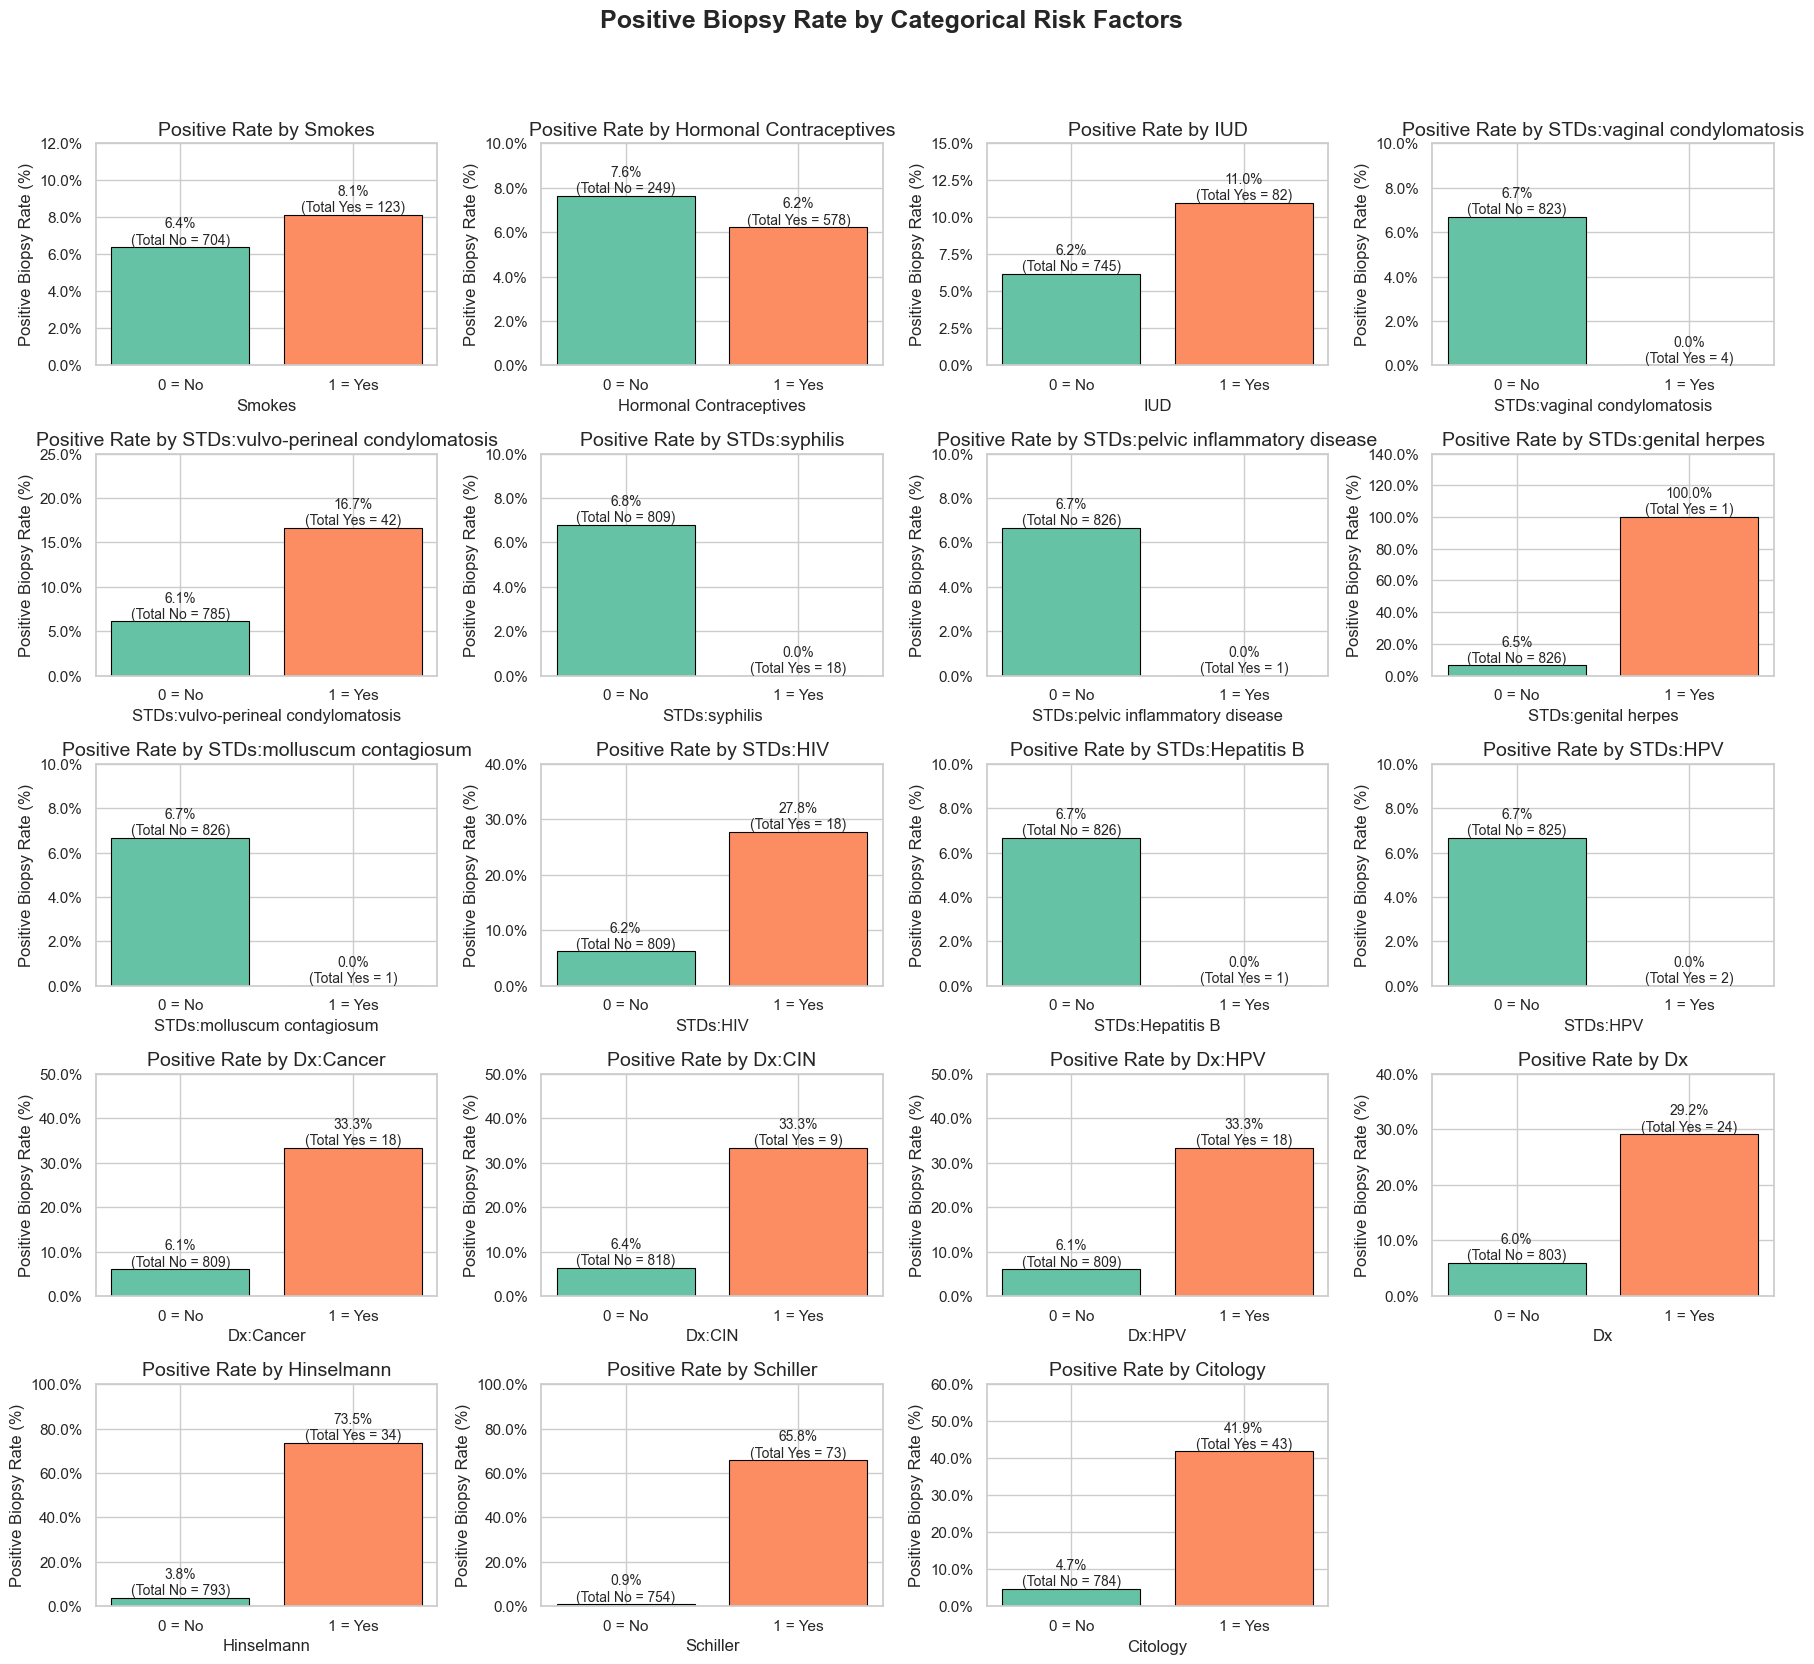

In [32]:
# Cell 9
print("==========================================")
print("PHASE 3, STEP 3: CATEGORICAL FEATURE INVESTIGATION")
print("==========================================")

# Dynamically select binary categorical features
categorical_features = [col for col in df.columns if set(df[col].dropna().unique()).issubset({0.0, 1.0}) and col != 'Biopsy']

# Determine dynamic grid dimensions
n_features = len(categorical_features)
n_cols = 4  
n_rows = (n_features - 1) // n_cols + 1  

# Set up the dynamic grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
fig.suptitle('Positive Biopsy Rate by Categorical Risk Factors', fontsize=18, fontweight='bold')

axes = axes.flatten()

# Extract 'Set2' hex codes to maintain your exact color scheme
color_no = '#66c2a5'  # Set2 Green
color_yes = '#fc8d62' # Set2 Orange

for i, feature in enumerate(categorical_features):
    ax = axes[i]
    
    # Rigorously calculate the exact rates and counts from the dataframe
    rates = []
    counts = []
    
    for cat in [0.0, 1.0]:
        subset = df[df[feature] == cat]
        count = len(subset)
        counts.append(count)
        
        if count > 0:
            # Calculate the mathematical mean (Positive Rate)
            rate = subset['Biopsy'].mean()
            # Handle edge cases where Biopsy data might be entirely NaN for this subset
            rate = 0.0 if pd.isna(rate) else rate
        else:
            # If the category doesn't exist in the data, the rate is strictly 0
            rate = 0.0
            
        rates.append(rate)
        
    # Draw bars using absolute Matplotlib geometry to prevent Seaborn artifacts
    bars = ax.bar(
        x=[0, 1], 
        height=rates, 
        color=[color_no, color_yes],
        edgecolor='black', # Forces a visible line even if height is exactly 0
        linewidth=0.8
    )
    
    ax.set_title(f'Positive Rate by {feature}', fontsize=14)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0 = No', '1 = Yes'])
    ax.set_xlabel(f'{feature}')
    ax.set_ylabel('Positive Biopsy Rate (%)')
    
    # Map the text perfectly to the static coordinates
    max_rate = max(rates)
    
    for j, bar in enumerate(bars):
        # Only annotate the bar if the data actually exists in the dataset
        if counts[j] > 0:
            label = f'{rates[j]:.1%}\n(Total {"No" if j == 0 else "Yes"} = {counts[j]})'
            ax.text(
                x=bar.get_x() + bar.get_width() / 2, 
                y=rates[j], 
                s=label, 
                ha='center', 
                va='bottom', 
                fontsize=10
            )
            
    # Dynamically scale the y-axis, ensuring a minimum bound so 0% plots do not squash
    ymax = max_rate * 1.3 if max_rate > 0 else 0.1
    ax.set_ylim(0, ymax) 
    
    # Format the y-axis as percentages
    vals = ax.get_yticks()
    ax.set_yticks(vals) 
    ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])
    
# Cleanly hide any remaining unused subplots 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust global spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Step 4: Statistical significance testing

In [33]:
# Cell 10
print("==========================================")
print("PHASE 3, STEP 4: STATISTICAL SIGNIFICANCE TESTING")
print("==========================================")

# ---------------------------------------------------------
# 1. Continuous Features (Mann-Whitney U Test)
# ---------------------------------------------------------
print("--- Continuous Features (Target: Biopsy) ---")
print("Null Hypothesis: The feature distribution is the same for Negative and Positive biopsies.\n")

continuous_features = [
    'Age', 'Number of sexual partners', 'Num of pregnancies', 
    'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 
    'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis'
]

# Only test columns that still exist in our dataframe
for feature in continuous_features:
    if feature in df.columns:
        group_neg = df[df['Biopsy'] == 0][feature].dropna()
        group_pos = df[df['Biopsy'] == 1][feature].dropna()
        
        stat, p_value = stats.mannwhitneyu(group_neg, group_pos, alternative='two-sided')
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"- {feature:32} | p-value: {p_value:.4f} ({significance})")

# ---------------------------------------------------------
# 2. Categorical Features (Chi-Square Test)
# ---------------------------------------------------------
print("\n--- Categorical Features (Target: Biopsy) ---")
print("Null Hypothesis: The feature and Biopsy result are independent.\n")

# Dynamically find all binary categorical columns (excluding our target 'Biopsy')
categorical_features = [col for col in df.columns if set(df[col].dropna().unique()).issubset({0.0, 1.0}) and col != 'Biopsy']

for feature in categorical_features:
    # Ensure the column actually has variance (has both 0s and 1s) to avoid math errors
    if df[feature].nunique() > 1:
        contingency_table = pd.crosstab(df[feature], df['Biopsy'])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
        
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"- {feature:32} | p-value: {p_value:.4f} ({significance})")

PHASE 3, STEP 4: STATISTICAL SIGNIFICANCE TESTING
--- Continuous Features (Target: Biopsy) ---
Null Hypothesis: The feature distribution is the same for Negative and Positive biopsies.

- Age                              | p-value: 0.2116 (Not Significant)
- Number of sexual partners        | p-value: 0.8915 (Not Significant)
- Num of pregnancies               | p-value: 0.1117 (Not Significant)
- Smokes (years)                   | p-value: 0.4022 (Not Significant)
- Smokes (packs/year)              | p-value: 0.4073 (Not Significant)
- Hormonal Contraceptives (years)  | p-value: 0.7402 (Not Significant)
- IUD (years)                      | p-value: 0.0963 (Not Significant)
- STDs (number)                    | p-value: 0.0012 (SIGNIFICANT)
- STDs: Number of diagnosis        | p-value: 0.0016 (SIGNIFICANT)

--- Categorical Features (Target: Biopsy) ---
Null Hypothesis: The feature and Biopsy result are independent.

- Smokes                           | p-value: 0.6047 (Not Significant)


PHASE 3, STEP 3: SIGNIFICANT CATEGORICAL FEATURES ONLY
--- Executing Statistical Significance Filter (α = 0.05) ---
[Keep] STDs:vulvo-perineal condylomatosis  | p-value: 0.0169 (SIGNIFICANT)
[Keep] STDs:HIV                            | p-value: 0.0048 (SIGNIFICANT)
[Keep] Dx:Cancer                           | p-value: 0.0007 (SIGNIFICANT)
[Keep] Dx:CIN                              | p-value: 0.0176 (SIGNIFICANT)
[Keep] Dx                                  | p-value: 0.0006 (SIGNIFICANT)
[Keep] Hinselmann                          | p-value: 0.0000 (SIGNIFICANT)
[Keep] Schiller                            | p-value: 0.0000 (SIGNIFICANT)
[Keep] Citology                            | p-value: 0.0000 (SIGNIFICANT)

Filtered down to 8 statistically significant clinical signals.



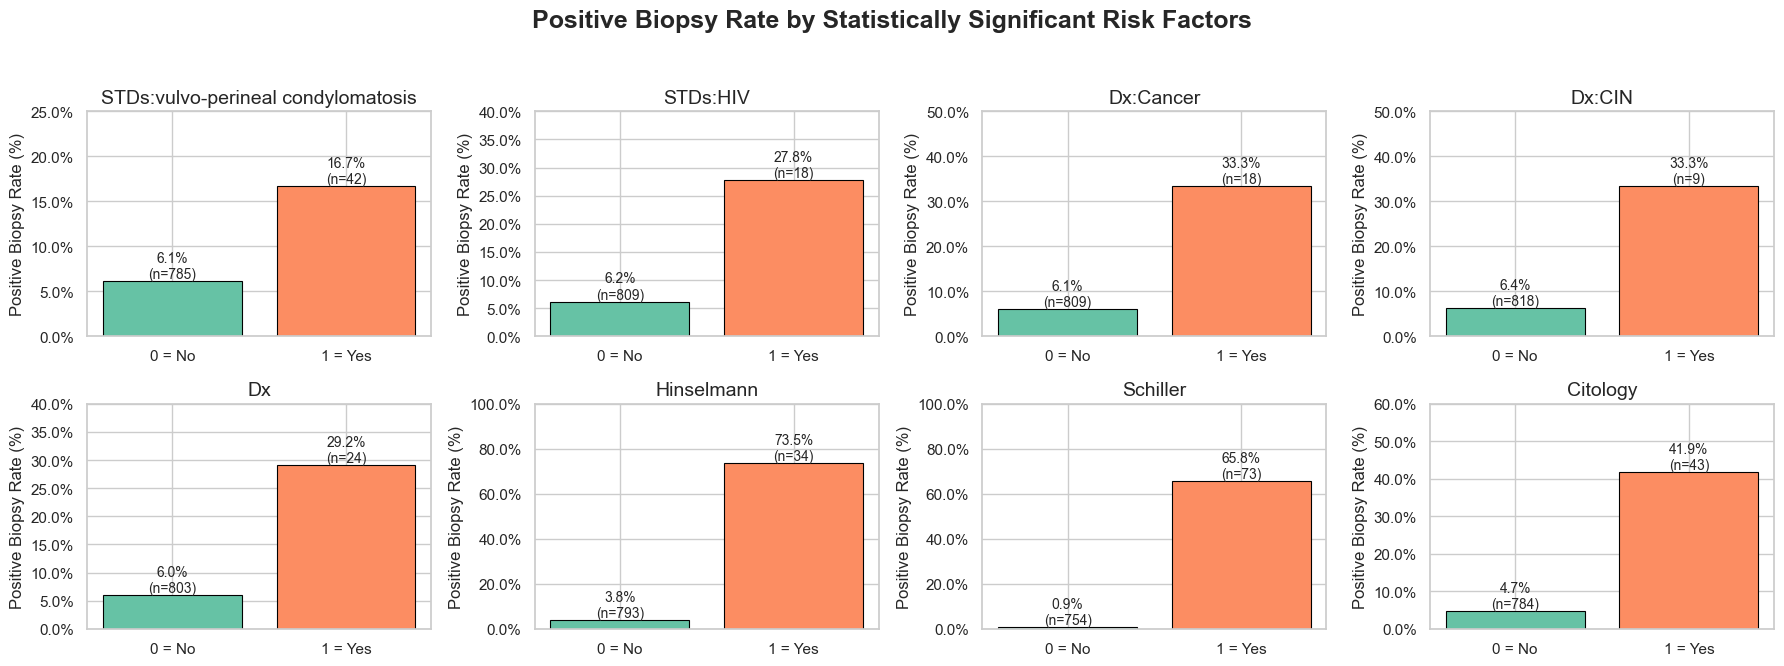

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

print("==========================================")
print("PHASE 3, STEP 3: SIGNIFICANT CATEGORICAL FEATURES ONLY")
print("==========================================")

# 1. Isolate all binary categorical features (Explicitly excluding the target and redundant Dx:HPV)
categorical_features = [
    col for col in df.columns 
    if set(df[col].dropna().unique()).issubset({0.0, 1.0}) 
    and col not in ['Biopsy', 'Dx:HPV']
]

significant_features = []
alpha = 0.05

# 2. Mathematically filter for significance using Fisher's Exact Test
print("--- Executing Statistical Significance Filter (\u03B1 = 0.05) ---")
for feature in categorical_features:
    # Build 2x2 contingency table: [[Feature=0/Biopsy=0, Feature=0/Biopsy=1], [Feature=1/Biopsy=0, Feature=1/Biopsy=1]]
    crosstab = pd.crosstab(df[feature], df['Biopsy'])
    
    # Ensure it is a valid 2x2 table before running the calculation
    if crosstab.shape == (2, 2):
        _, p_value = fisher_exact(crosstab)
        if p_value < alpha:
            significant_features.append(feature)
            print(f"[Keep] {feature:35} | p-value: {p_value:.4f} (SIGNIFICANT)")
    else:
        pass # Drop features with zero variance in the current data split

print(f"\nFiltered down to {len(significant_features)} statistically significant clinical signals.\n")

# 3. Dynamic Grid Setup for Survivors
n_features = len(significant_features)

if n_features == 0:
    print("No significant features found to plot.")
else:
    # Set columns to a maximum of 4, adjust rows accordingly
    n_cols = min(4, n_features) 
    n_rows = (n_features - 1) // n_cols + 1  

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    fig.suptitle('Positive Biopsy Rate by Statistically Significant Risk Factors', fontsize=18, fontweight='bold')

    # Ensure axes is iterable even if only 1 feature survives
    if n_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    color_no = '#66c2a5'  # Set2 Green
    color_yes = '#fc8d62' # Set2 Orange

    for i, feature in enumerate(significant_features):
        ax = axes[i]
        
        rates = []
        counts = []
        
        for cat in [0.0, 1.0]:
            subset = df[df[feature] == cat]
            count = len(subset)
            counts.append(count)
            
            if count > 0:
                rate = subset['Biopsy'].mean()
                rate = 0.0 if pd.isna(rate) else rate
            else:
                rate = 0.0
                
            rates.append(rate)
            
        # Draw bars using absolute Matplotlib geometry
        bars = ax.bar(
            x=[0, 1], 
            height=rates, 
            color=[color_no, color_yes],
            edgecolor='black',
            linewidth=0.8
        )
        
        ax.set_title(f'{feature}', fontsize=14)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['0 = No', '1 = Yes'])
        ax.set_ylabel('Positive Biopsy Rate (%)')
        
        max_rate = max(rates)
        
        for j, bar in enumerate(bars):
            if counts[j] > 0:
                label = f'{rates[j]:.1%}\n(n={counts[j]})'
                ax.text(
                    x=bar.get_x() + bar.get_width() / 2, 
                    y=rates[j], 
                    s=label, 
                    ha='center', 
                    va='bottom', 
                    fontsize=10
                )
                
        ymax = max_rate * 1.3 if max_rate > 0 else 0.1
        ax.set_ylim(0, ymax) 
        
        vals = ax.get_yticks()
        ax.set_yticks(vals) 
        ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])

    # Cleanly hide any remaining unused subplots in the final row
    if n_features > 1:
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [38]:
import pandas as pd

print("==========================================")
print("CLINICAL OVERLAP AUDIT: Dx:Cancer vs Dx:HPV")
print("==========================================\n")

# 1. Verify the exact Pearson Correlation
corr_val = df['Dx:Cancer'].corr(df['Dx:HPV'])
print(f"Calculated Pearson Correlation: {corr_val:.4f}\n")

# 2. Construct the exact Contingency Table
# This shows us the true overlap and the distinct mismatches
crosstab = pd.crosstab(
    df['Dx:Cancer'], 
    df['Dx:HPV'], 
    rownames=['Dx:Cancer (Rows)'], 
    colnames=['Dx:HPV (Cols)'],
    margins=True # Adds row/col totals
)

print("--- Contingency Matrix ---")
print(crosstab)
print("\n")

# 3. Isolate the Discrepant Patients
# Find the exact rows where the two flags do not perfectly match
mismatches = df[df['Dx:Cancer'] != df['Dx:HPV']]
mismatch_count = len(mismatches)

print(f"--- Discrepant Patient Audit (Total: {mismatch_count}) ---")

if mismatch_count == 0:
    print("Zero mismatches found. The columns are perfectly identical.")
    print("If your correlation is not 1.0, there is a severe floating-point or memory error in your environment.")
else:
    print(f"Found {mismatch_count} patients preventing a perfect 1.0 correlation.")
    # Display the specific patients and their target variable outcome
    columns_to_show = ['Age', 'Dx:Cancer', 'Dx:HPV', 'Biopsy']
    
    # Ensure all requested columns exist before printing to prevent KeyError
    valid_columns = [c for c in columns_to_show if c in df.columns]
    print(mismatches[valid_columns].to_string())

CLINICAL OVERLAP AUDIT: Dx:Cancer vs Dx:HPV

Calculated Pearson Correlation: 0.8864

--- Contingency Matrix ---
Dx:HPV (Cols)       0   1  All
Dx:Cancer (Rows)              
0                 807   2  809
1                   2  16   18
All               809  18  827


--- Discrepant Patient Audit (Total: 4) ---
Found 4 patients preventing a perfect 1.0 correlation.
     Age  Dx:Cancer  Dx:HPV  Biopsy
107   32          0       1       0
362   21          0       1       0
417   31          1       0       0
808   31          1       0       0


In [39]:
print("--- Correlation with Target Variable (Biopsy) ---")
print(df[['Dx:Cancer', 'Dx:HPV', 'Biopsy']].corr()['Biopsy'].drop('Biopsy').sort_values(ascending=False))

--- Correlation with Target Variable (Biopsy) ---
Dx:HPV       0.159738
Dx:Cancer    0.159738
Name: Biopsy, dtype: float64


In [34]:
print("STDs:HPV counts:\n", df['STDs:HPV'].value_counts())
print("\nDx:HPV counts:\n", df['Dx:HPV'].value_counts())

print("\nNum of pregnancies counts:\n", df['Num of pregnancies'].value_counts())
print("\nSTDs: Number of diagnosis:\n", df['STDs: Number of diagnosis'].value_counts())

STDs:HPV counts:
 STDs:HPV
0.0    825
1.0      2
Name: count, dtype: int64

Dx:HPV counts:
 Dx:HPV
0    809
1     18
Name: count, dtype: int64

Num of pregnancies counts:
 Num of pregnancies
2.0     281
1.0     256
3.0     137
4.0      73
5.0      35
6.0      18
0.0      17
7.0       6
8.0       2
11.0      1
10.0      1
Name: count, dtype: int64

STDs: Number of diagnosis:
 STDs: Number of diagnosis
0    757
1     67
2      2
3      1
Name: count, dtype: int64
